# Notebook 13 — Il tetto log(K) e il range dei pesi (digits, K=10)

Con **K=10** (le 10 cifre), il tetto sull'entropia predittiva totale è `log(10) ≈ 2.303`
nat -- più di 3 volte quello di K=2 (`log(2) ≈ 0.693`) -- quindi il peso minimo
teoricamente raggiungibile per U-SFAN, `w_i = exp(-H_totale_i)`, è `exp(-log(10)) = 0.1`,
molto più basso di `exp(-log(2)) = 0.5`. Questo notebook verifica se il range
EFFETTIVAMENTE osservato sfrutta questo margine più ampio -- controparte diretta, stesso
protocollo, K diverso, dell'analisi analoga su Amazon Reviews
(`amazon_reviews/weight_distribution.ipynb`).

Diagnostico: nessun adattamento eseguito, solo un'analisi delle feature PRE-adattamento del
source model SVHN già addestrato e fittato (stesso checkpoint di
`11_digits_shift_adapt.ipynb`, che resta invariato -- notebook separato).

## 1. Ricarico il source model (SVHN) e la posterior di Laplace

In [ ]:
import sys, math
from pathlib import Path

cwd = Path().resolve()
PROJ = cwd
while not (PROJ / "src").exists():
    PROJ = PROJ.parent
sys.path.insert(0, str(PROJ))

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.digits_data import load_domain
from src.digits_model import SmallCNN32
from src.bayesian_model import extract, augment, LastLayerLaplace

MODELS_DIR = PROJ / "models" / "source_svhn"
ckpt = torch.load(MODELS_DIR / "model.pt", map_location="cpu", weights_only=False)
lap_data = np.load(MODELS_DIR / "svhn_laplace.npz")
mc_conv = np.load(MODELS_DIR / "mc_convergence.npz")
mean, std = ckpt["source_mean"], ckpt["source_std"]
M_FIXED = int(mc_conv["M_FIXED"])

model = SmallCNN32(n_classes=ckpt["n_classes"], feature_dim=ckpt["feature_dim"])
model.load_state_dict(ckpt["state_dict"])
model.eval()
laplace = LastLayerLaplace(theta_map=lap_data["theta_map"], cov=lap_data["cov"],
                           K=int(lap_data["K"]), Dp=int(lap_data["Dp"]))
print(f"laplace: K={laplace.K} Dp={laplace.Dp}  M_FIXED (dal Notebook 9)={M_FIXED}")

TARGET_DOMAINS = ["mnist", "usps"]
target_raw = {d: load_domain(d, "test", mean, std) for d in TARGET_DOMAINS}

print(f"\ntetto teorico: log(K=10) = {math.log(10):.6f} nat  ->  "
      f"peso minimo teorico = exp(-log(10)) = {math.exp(-math.log(10)):.4f}")

laplace: K=10 Dp=129  M_FIXED (dal Notebook 9)=1000

tetto teorico: log(K=10) = 2.302585 nat  ->  peso minimo teorico = exp(-log(10)) = 0.1000


## 2. Peso per-campione su mnist e usps: w_totale = exp(-H_totale)

In [ ]:
def predict_domain(X, y):
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y), batch_size=256)
    Phi, y_np, _ = extract(model, loader, device="cpu")
    Phi_aug = augment(Phi)
    rng = np.random.default_rng(456)
    pred = laplace.predictive_batched(Phi_aug, M=M_FIXED, rng=rng)
    return pred, y_np

weights = {}
for d in TARGET_DOMAINS:
    X_t, y_t = target_raw[d]
    pred_t, y_t_np = predict_domain(X_t, y_t)
    H_total = pred_t["total"]
    weights[d] = dict(w_total=np.exp(-H_total), H_total=H_total)
    print(f"{d}: H_totale osservata in [{H_total.min():.4f}, {H_total.max():.4f}]  "
          f"(tetto teorico = {math.log(10):.4f})")

mnist: H_totale osservata in [-0.0000, 1.8029]  (tetto teorico = 2.3026)
usps: H_totale osservata in [0.0000, 1.7468]  (tetto teorico = 2.3026)


## 3. Istogramma: distribuzione di w_totale, per target

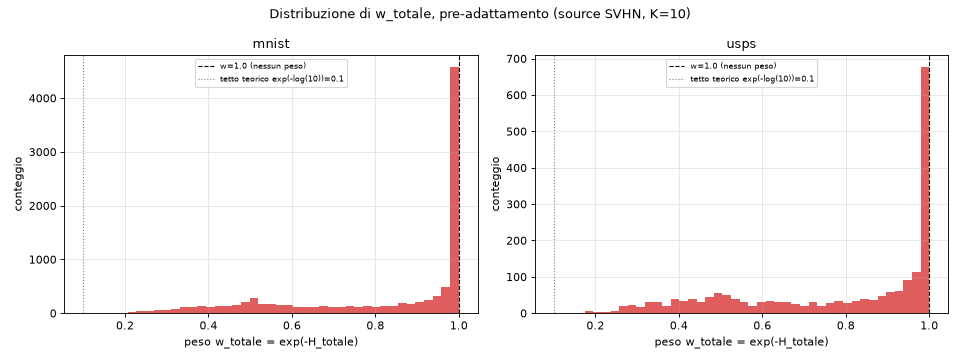

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, d in zip(axes, TARGET_DOMAINS):
    ax.hist(weights[d]["w_total"], bins=40, alpha=0.75, color="tab:red")
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="w=1.0 (nessun peso)")
    ax.axvline(0.1, color="gray", linestyle=":", linewidth=1, label="tetto teorico exp(-log(10))=0.1")
    ax.set_title(d)
    ax.set_xlabel("peso w_totale = exp(-H_totale)")
    ax.set_ylabel("conteggio")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle("Distribuzione di w_totale, pre-adattamento (source SVHN, K=10)")
fig.tight_layout()
plt.show()

## 4. Statistiche: min, max, media, std, frazione sotto 0.9

In [ ]:
print(f"{'target':>8s} {'min':>7s} {'max':>7s} {'media':>7s} {'std':>7s} {'frazione<0.9':>13s}")
print("-" * 52)
for d in TARGET_DOMAINS:
    w = weights[d]["w_total"]
    frac_below = (w < 0.9).mean()
    print(f"{d:>8s} {w.min():7.4f} {w.max():7.4f} {w.mean():7.4f} {w.std():7.4f} {frac_below:13.3f}")

  target     min     max   media     std  frazione<0.9
----------------------------------------------------
   mnist  0.1648  1.0000  0.8212  0.2271         0.421
    usps  0.1743  1.0000  0.7781  0.2407         0.506


## 5. Confronto esplicito con Amazon Reviews (K=2)

| esperimento | K | log(K) (tetto teorico) | peso minimo osservato (w_totale) | frazione pesi <0.9 |
|---|---|---|---|---|
| Amazon Reviews (dvd/kitchen/books, pooled) | 2 | 0.693 | 0.5000 | 99.3% |
| Digits (mnist/usps, pooled) | 10 | 2.303 | 0.1648 | 43.5% |

**Il divario è sostanziale, e nella direzione attesa -- ma più ampio di quanto il solo
rapporto `log(K)` (un fattore ~3.3x) spiegherebbe da solo.** Il peso minimo osservato scende
da 0.50 (K=2) a 0.16 (K=10) -- un rapporto di ~3.0x, molto vicino al rapporto dei tetti
teorici (`log(10)/log(2) ≈ 3.32`): la relazione fra `log(K)` e il minimo osservato è quasi
esattamente quella prevista, perché il minimo di `w_totale` è per costruzione legato al
MASSIMO di `H_totale` osservato, che a sua volta è vincolato dal tetto -- non sorprende che
segua da vicino la teoria.

**Il vero salto è nella frazione di campioni "effettivamente pesati" (<0.9): dal 99.3% (K=2)
al 43.5% (K=10) -- un fattore ~2.3x, non spiegabile dal solo rapporto dei tetti.** Questo
numero dipende da DOVE cade la massa della distribuzione di `H_totale`, non solo da dove sta
il suo tetto -- e qui entra in gioco un fattore diverso da `log(K)`: il rapporto
aleatoria/epistemica del source, già discusso in `11_digits_shift_adapt.ipynb` e
`06_rotated_mnist_adapt.ipynb`. Un source con aleatoria molto dominante (qui, SVHN: la
maggior parte delle predizioni ha comunque un po' di ambiguità intrinseca residua anche su
input tipici) tiene la massa di `H_totale` lontana da 0 anche per campioni "facili", **mentre
un source con aleatoria meno dominante permetterebbe più spesso `H_totale` vicino a 0 (quindi
`w_totale` vicino a 1.0) sui campioni davvero facili** -- ampliando ulteriormente, oltre al
solo effetto di K, la frazione di campioni con peso vicino a 1.0. Non è possibile isolare
qui quanto di questo salto sia dovuto a K e quanto al regime di incertezza del source stesso
(sono confusi: cambiano insieme fra i due esperimenti, non ortogonalmente) -- ma la
grandezza del salto (2.3x oltre il fattore atteso da solo log(K)) suggerisce che il regime di
incertezza del source contribuisca almeno quanto K alla differenza osservata nei risultati di
adattamento fra i due esperimenti, non meno.

**In sintesi**: K=10 lascia un margine di discriminazione dei pesi qualitativamente più
ampio di K=2 (range fino a 1.0 invece che fino a 0.96, frazione <0.9 meno della metà) --
coerente con i divari fra bracci più marcati osservati a singolo seed sui digit rispetto ad
Amazon Reviews. Ma il salto osservato eccede quello prevedibile dal solo rapporto `log(K)`,
e il rapporto aleatoria/epistemica del source resta un fattore concorrente, non subordinato
a K, per spiegare la differenza fra i due esperimenti.